In [ ]:
!pip install yfinance pandas numpy -q

In [ ]:
import os
import numpy as np
import pandas as pd
import yfinance as yf

# === Config ===
RAW_DATA_DIR = "data/raw"
PROCESSED_DATA_DIR = "data/processed"
START_DATE = "2005-01-01"
END_DATE = "2025-12-31"

os.makedirs(RAW_DATA_DIR, exist_ok=True)
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

# VIX term structure tickers on Yahoo Finance
VIX_YF_MAP = {
    "VIX":   "^VIX",
    "VIX3M": "^VIX3M",
    "VIX6M": "^VIX6M",
    "VIX1Y": "^VIX1Y",
}


In [ ]:
def fetch_vix_term_structure() -> pd.DataFrame:
    """Download VIX, VIX3M, VIX6M, VIX1Y from Yahoo Finance."""
    path = os.path.join(RAW_DATA_DIR, "vix_term_structure.csv")
    if os.path.exists(path):
        print(f"  [cache] Loading {path}")
        return pd.read_csv(path, index_col="Date", parse_dates=True)

    frames = {}
    for label, ticker in VIX_YF_MAP.items():
        print(f"  Downloading {label} ({ticker})...")
        try:
            df = yf.download(ticker, start=START_DATE, end=END_DATE, auto_adjust=True)
            if len(df) > 0:
                frames[label] = df["Close"].squeeze()
                print(f"    -> {len(df)} rows")
            else:
                print(f"    -> empty, skipping")
        except Exception as e:
            print(f"    -> failed ({e}), skipping")

    vix = pd.DataFrame(frames)
    vix.index.name = "Date"
    vix.to_csv(path)
    print(f"  Saved -> {path}  ({len(vix)} rows)")
    return vix


In [ ]:
def derive_term_structure_features(vix: pd.DataFrame) -> pd.DataFrame:
    """
    From raw VIX levels, compute:
      - slope_3m_spot:  VIX3M - VIX  (term structure slope, near-end)
      - slope_6m_3m:    VIX6M - VIX3M (term structure slope, far-end)
      - curvature:      VIX - 2*VIX3M + VIX6M  (is the curve bowed?)
      - contango_flag:  1 if VIX3M > VIX (normal), 0 if backwardated (stress)
      - vix_1d_change:  daily pct change in VIX
      - vix_5d_change:  5-day pct change in VIX
      - vix_zscore_20d: how many stdev VIX is from its 20-day mean
    """
    feat = vix.copy()

    # Slopes
    if "VIX" in feat.columns and "VIX3M" in feat.columns:
        feat["slope_3m_spot"] = feat["VIX3M"] - feat["VIX"]
    if "VIX3M" in feat.columns and "VIX6M" in feat.columns:
        feat["slope_6m_3m"] = feat["VIX6M"] - feat["VIX3M"]

    # Curvature
    if all(c in feat.columns for c in ["VIX", "VIX3M", "VIX6M"]):
        feat["curvature"] = feat["VIX"] - 2 * feat["VIX3M"] + feat["VIX6M"]

    # Contango / backwardation
    if "slope_3m_spot" in feat.columns:
        feat["contango_flag"] = (feat["slope_3m_spot"] > 0).astype(int)

    # VIX momentum
    if "VIX" in feat.columns:
        feat["vix_1d_change"] = feat["VIX"].pct_change()
        feat["vix_5d_change"] = feat["VIX"].pct_change(5)
        feat["vix_zscore_20d"] = (
            (feat["VIX"] - feat["VIX"].rolling(20).mean())
            / feat["VIX"].rolling(20).std()
        )

    return feat


def build_synthetic_surface(feat: pd.DataFrame) -> pd.DataFrame:
    """
    Without IBKR options data, derive proxy surface features from VIX.
    These approximate what the real options surface would tell us:
      - atm_iv_proxy:     VIX/100 as proxy for ATM implied vol
      - skew_proxy:       term structure slope proxies for skew
      - vix_ma_ratio:     VIX / 60-day MA (mean reversion signal)
    """
    surface = pd.DataFrame(index=feat.index)
    if "VIX" in feat.columns:
        surface["atm_iv_proxy"] = feat["VIX"] / 100
        surface["vix_ma_ratio"] = feat["VIX"] / feat["VIX"].rolling(60).mean()
    if "slope_3m_spot" in feat.columns:
        surface["skew_proxy"] = feat["slope_3m_spot"]
    return surface


In [ ]:
print("=" * 60)
print("P1 — LSTM Autoencoder Data Pipeline")
print("=" * 60)

# Step 1: Download VIX term structure
print("\n[1/3] Fetching VIX term structure...")
vix_raw = fetch_vix_term_structure()
print(f"  Columns: {list(vix_raw.columns)}")
print(f"  Date range: {vix_raw.index.min()} to {vix_raw.index.max()}")

# Step 2: Derive features
print("\n[2/3] Deriving term structure features...")
vix_feat = derive_term_structure_features(vix_raw)
print(f"  Features: {list(vix_feat.columns)}")

# Step 3: Synthetic surface (IBKR fallback)
print("\n[3/3] Building synthetic surface features (IBKR not available in Colab)...")
surface = build_synthetic_surface(vix_feat)
print(f"  Surface features: {list(surface.columns)}")

# Combine
combined = vix_feat.join(surface, how="outer").ffill().dropna()
combined.to_csv(os.path.join(PROCESSED_DATA_DIR, "p1_combined_features.csv"))
print(f"\nCombined: {combined.shape[0]} rows, {combined.shape[1]} features")
print(f"Features: {list(combined.columns)}")
print("\nDone!")


P1 — LSTM Autoencoder Data Pipeline

[1/3] Fetching VIX term structure...


[*********************100%***********************]  1 of 1 completed


    -> 5282 rows


[*********************100%***********************]  1 of 1 completed


    -> 4896 rows


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['^VIX1Y']: YFPricesMissingError('possibly delisted; no price data found  (1d 2005-01-01 -> 2025-12-31)')


    -> 4528 rows
    -> empty, skipping
  Saved -> data/raw/vix_term_structure.csv  (5282 rows)
  Columns: ['VIX', 'VIX3M', 'VIX6M']
  Date range: 2005-01-03 00:00:00 to 2025-12-30 00:00:00

[2/3] Deriving term structure features...
  Features: ['VIX', 'VIX3M', 'VIX6M', 'slope_3m_spot', 'slope_6m_3m', 'curvature', 'contango_flag', 'vix_1d_change', 'vix_5d_change', 'vix_zscore_20d']

[3/3] Building synthetic surface features (IBKR not available in Colab)...
  Surface features: ['atm_iv_proxy', 'vix_ma_ratio', 'skew_proxy']

Combined: 4528 rows, 13 features
Features: ['VIX', 'VIX3M', 'VIX6M', 'slope_3m_spot', 'slope_6m_3m', 'curvature', 'contango_flag', 'vix_1d_change', 'vix_5d_change', 'vix_zscore_20d', 'atm_iv_proxy', 'vix_ma_ratio', 'skew_proxy']

Done!


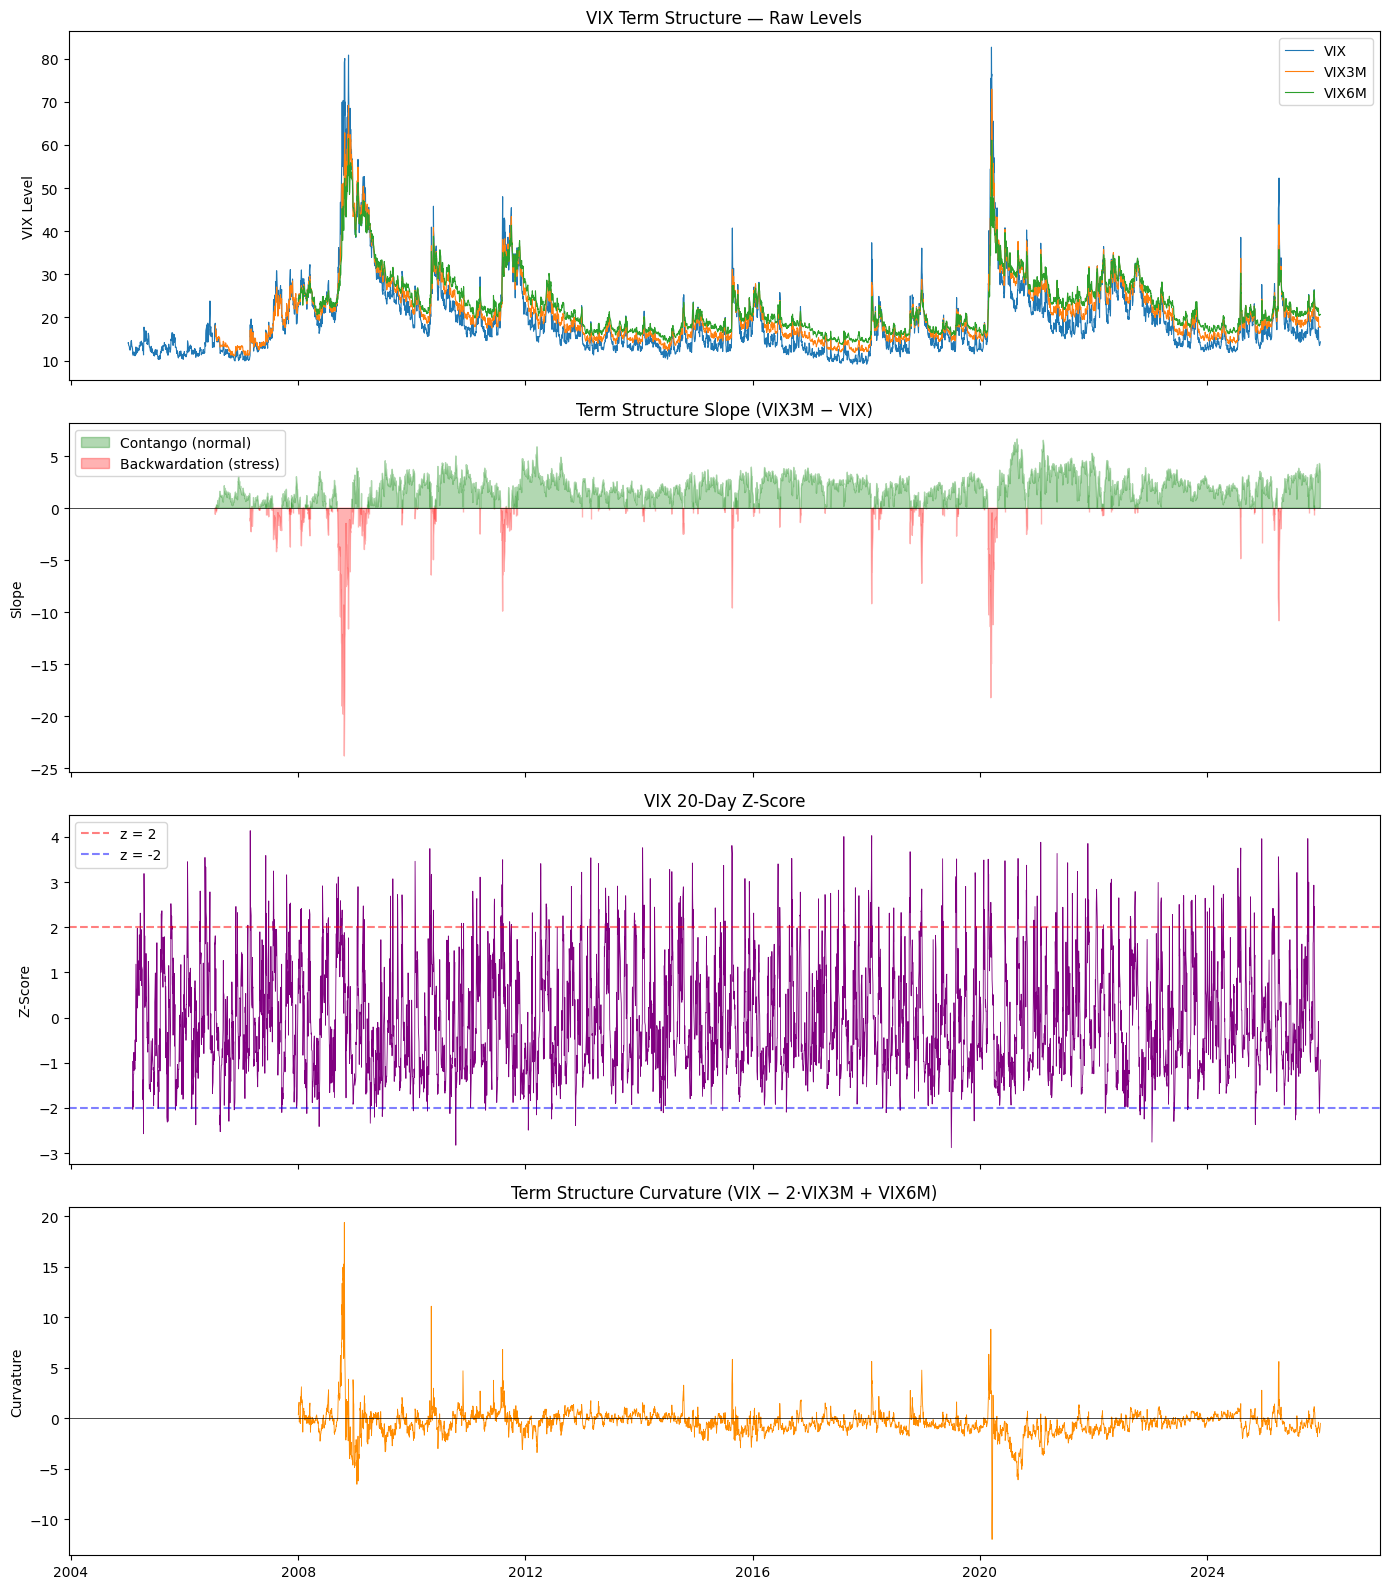

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# Plot 1: Raw VIX levels
ax = axes[0]
for col in ["VIX", "VIX3M", "VIX6M"]:
    if col in vix_raw.columns:
        ax.plot(vix_raw.index, vix_raw[col], linewidth=0.8, label=col)
ax.set_title("VIX Term Structure — Raw Levels")
ax.set_ylabel("VIX Level")
ax.legend()

# Plot 2: Term structure slope (contango vs backwardation)
ax = axes[1]
if "slope_3m_spot" in vix_feat.columns:
    slope = vix_feat["slope_3m_spot"]
    ax.fill_between(slope.index, slope, 0,
                    where=slope > 0, color="green", alpha=0.3, label="Contango (normal)")
    ax.fill_between(slope.index, slope, 0,
                    where=slope <= 0, color="red", alpha=0.3, label="Backwardation (stress)")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title("Term Structure Slope (VIX3M − VIX)")
    ax.set_ylabel("Slope")
    ax.legend()

# Plot 3: VIX z-score
ax = axes[2]
if "vix_zscore_20d" in vix_feat.columns:
    zscore = vix_feat["vix_zscore_20d"]
    ax.plot(zscore.index, zscore, linewidth=0.6, color="purple")
    ax.axhline(2, color="red", linestyle="--", alpha=0.5, label="z = 2")
    ax.axhline(-2, color="blue", linestyle="--", alpha=0.5, label="z = -2")
    ax.set_title("VIX 20-Day Z-Score")
    ax.set_ylabel("Z-Score")
    ax.legend()

# Plot 4: Curvature
ax = axes[3]
if "curvature" in vix_feat.columns:
    ax.plot(vix_feat.index, vix_feat["curvature"], linewidth=0.6, color="darkorange")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title("Term Structure Curvature (VIX − 2·VIX3M + VIX6M)")
    ax.set_ylabel("Curvature")

plt.tight_layout()
plt.show()


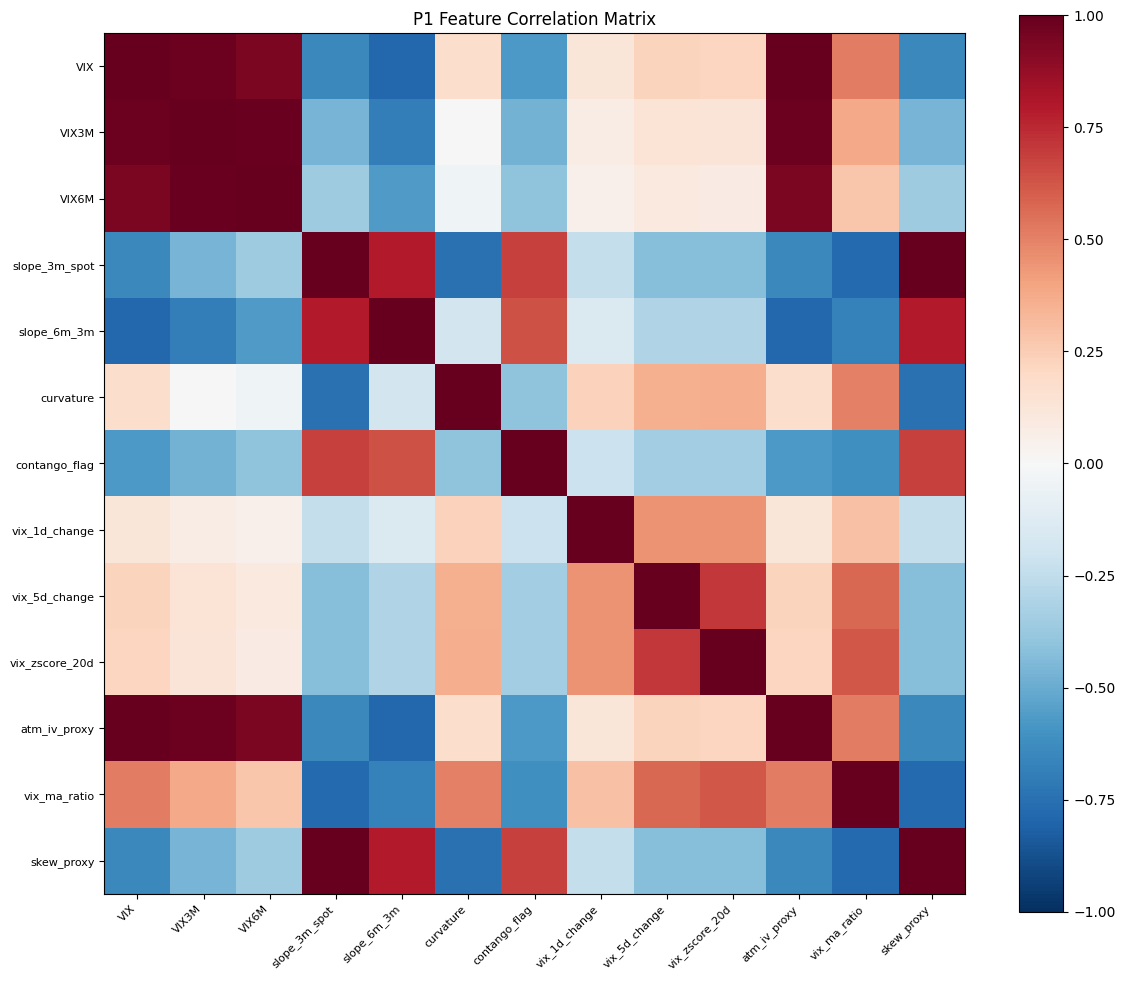

Highly correlated pairs (|r| > 0.9):
  VIX <-> VIX3M: 0.977
  VIX <-> VIX6M: 0.941
  VIX <-> atm_iv_proxy: 1.000
  VIX3M <-> VIX6M: 0.988
  VIX3M <-> atm_iv_proxy: 0.977
  VIX6M <-> atm_iv_proxy: 0.941
  slope_3m_spot <-> skew_proxy: 1.000


In [ ]:
# Quick correlation check — features should not be perfectly redundant
fig, ax = plt.subplots(figsize=(12, 10))
corr = combined.corr()
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
plt.colorbar(im)
ax.set_title("P1 Feature Correlation Matrix")
plt.tight_layout()
plt.show()

print("Highly correlated pairs (|r| > 0.9):")
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.9:
            print(f"  {corr.columns[i]} <-> {corr.columns[j]}: {corr.iloc[i, j]:.3f}")
